# CS 455 – Song2Vec: Music Recommender System
**Sabancı University – Spring 2025-2026**

## Setup

In [1]:
!pip install gensim umap-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.6 MB/s eta 0:00:00


In [2]:
import json
import os
import time
import math
from urllib.parse import unquote_plus
from collections import Counter
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.manifold import TSNE
from gensim.models import Word2Vec

# All random operations use this seed
SEED = 42
np.random.seed(SEED)

print("Setup complete.")

Setup complete.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR      = "/content/drive/MyDrive/CS455/Data"
MODEL_DIR     = "/content/drive/MyDrive/CS455/Models"
os.makedirs(MODEL_DIR, exist_ok=True)

PLAYLIST_PATH = f"{DATA_DIR}/playlist.idomaar"
TRACKS_PATH   = f"{DATA_DIR}/tracks.idomaar"

print(os.listdir(DATA_DIR))

Mounted at /content/drive
['albums.idomaar', 'persons.idomaar', 'users.idomaar', 'tracks.idomaar', 'tags.idomaar', 'playlist.idomaar']


---
## Part A – Data Preparation and Exploration
### A.1 – Data Loading and Preprocessing

In [5]:
# ── Step 1: Debug — inspect raw format of a few playlist lines

with open(PLAYLIST_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        # Use maxsplit=4 so col[4] is always the full remaining JSON,
        # even if the JSON itself contains tab characters.
        cols = line.rstrip("\n").split("\t", maxsplit=4)
        print(f"Line {i}: {len(cols)} columns")
        print(f"  col[3] (playlist meta) : {cols[3][:80]}")
        print(f"  col[4] (subjects/objs) : {cols[4][:80]}")
        print(f"  col[4] parsed type     : {type(json.loads(cols[4]))}")
        print()
        if i == 2:
            break

Line 0: 5 columns
  col[3] (playlist meta) : {"ID":2973549,"Title":"my_favorites","numtracks":27,"duration":6522}
  col[4] (subjects/objs) : {"subjects":[{"type":"user","id":41504}],"objects":[{"type":"track","id":3006631
  col[4] parsed type     : <class 'dict'>

Line 1: 5 columns
  col[3] (playlist meta) : {"ID":5429703,"Title":"","numtracks":9,"duration":2650}
  col[4] (subjects/objs) : {"subjects":[{"type":"user","id":41504}],"objects":[{"type":"track","id":2807573
  col[4] parsed type     : <class 'dict'>

Line 2: 5 columns
  col[3] (playlist meta) : {"ID":5926742,"Title":"1989","numtracks":16,"duration":3645}
  col[4] (subjects/objs) : {"subjects":[{"type":"user","id":44542}],"objects":[{"type":"track","id":2236990
  col[4] parsed type     : <class 'dict'>



In [6]:
# ── Step 2: Build track_id → 'artist__title' lookup from tracks.idomaar

def normalize(text: str) -> str:
    """Lowercase, replace spaces and hyphens with underscores."""
    return text.lower().replace(" ", "_").replace("-", "_")

def parse_track_name(raw_name: str):
    """
    raw_name is URL-encoded: 'Artist+Name/_/Track+Title'
    Returns 'artist__title' string, or None if malformed.
    """
    decoded = unquote_plus(raw_name)
    parts   = decoded.split("/_/")
    if len(parts) != 2:
        return None
    artist, title = parts
    return normalize(artist) + "__" + normalize(title)


track_lookup = {}   # { track_id (int) : 'artist__title' (str) }

with open(TRACKS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        cols = line.rstrip("\n").split("\t", maxsplit=4)
        if len(cols) < 4:
            continue
        try:
            track_id   = int(cols[1])
            meta       = json.loads(cols[3])
            identifier = parse_track_name(meta.get("name", ""))
            if identifier:
                track_lookup[track_id] = identifier
        except (json.JSONDecodeError, ValueError):
            continue

print(f"Track lookup size : {len(track_lookup):,}")
sample_id = next(iter(track_lookup))
print(f"Example           : id={sample_id}  →  '{track_lookup[sample_id]}'")

Track lookup size : 4,519,105
Example           : id=0  →  '000003_music_instructor__dj's_rock_da_house_â≈æ≈ê01___dj_max_pulemet_vs._bomfunk_mc's___electro_breakdance_party_1_[2000]_=_cd_oneâ≈æ≈ê'


In [7]:
# ── Step 3: Parse playlist.idomaar → list of song-identifier lists ──────────


all_playlists = []

with open(PLAYLIST_PATH, "r", encoding="utf-8") as f:
    for line in f:
        cols = line.rstrip("\n").split("\t", maxsplit=4)
        if len(cols) < 5:
            continue
        try:
            obj = json.loads(cols[4])
            track_ids = [
                item["id"]
                for item in obj.get("objects", [])
                if item.get("type") == "track"
            ]
            songs = [track_lookup[tid] for tid in track_ids if tid in track_lookup]
            if len(songs) >= 2:  # need ≥2 songs: context + target
                all_playlists.append(songs)
        except (json.JSONDecodeError, KeyError, AttributeError):
            continue

print(f"Total valid playlists       : {len(all_playlists):,}")
print(f"Example (first 5 tracks)    : {all_playlists[0][:5]}")

Total valid playlists       : 47,130
Example (first 5 tracks)    : ['the_whip__trash_(crookers_remix)', 'modeselektor__sucker_pin', 'simian_mobile_disco__hustler', 'gossip__standing_in_the_way_of_control', 'kalwi_&_remi__explosion_(dj_theo_remix)']


In [8]:
# ── Step 4: 80/20 train-test split at the PLAYLIST level

rng     = np.random.default_rng(SEED)
indices = rng.permutation(len(all_playlists))
split   = int(0.8 * len(all_playlists))

train_playlists = [all_playlists[i] for i in indices[:split]]
test_playlists  = [all_playlists[i] for i in indices[split:]]

print(f"Train playlists : {len(train_playlists):,}")
print(f"Test  playlists : {len(test_playlists):,}")

# Training-only frequency counter.
# Used for vocab estimates (Q3) and popularity classification (Q4).
# Must NOT include test playlists
train_track_counter = Counter(
    song for playlist in train_playlists for song in playlist
)
print(f"Unique tracks in training   : {len(train_track_counter):,}")

Train playlists : 37,704
Test  playlists : 9,426
Unique tracks in training   : 393,540


### A.2 – Exploratory Data Analysis

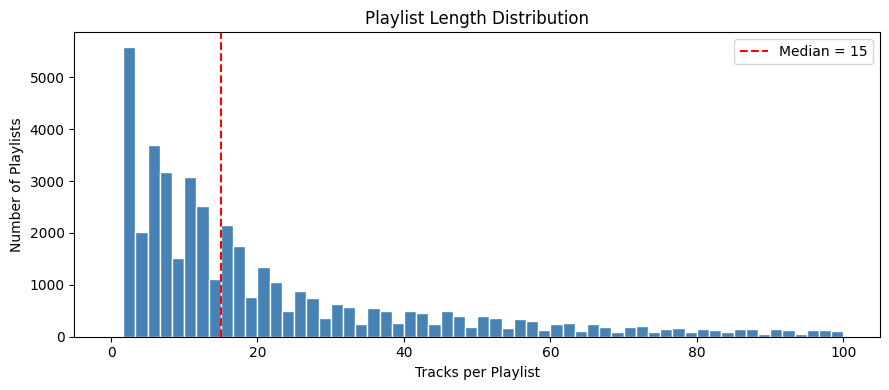

Min=2  Max=200  Mean=34.0  Median=15


In [ ]:
# Playlist length distribution
lengths = [len(p) for p in all_playlists]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lengths, bins=60, range=(0, 100), color="steelblue", edgecolor="white")
ax.axvline(np.median(lengths), color="red", linestyle="--",
           label=f"Median = {np.median(lengths):.0f}")
ax.set_xlabel("Tracks per Playlist")
ax.set_ylabel("Number of Playlists")
ax.set_title("Playlist Length Distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Min={min(lengths)}  Max={max(lengths)}  "
      f"Mean={np.mean(lengths):.1f}  Median={np.median(lengths):.0f}")

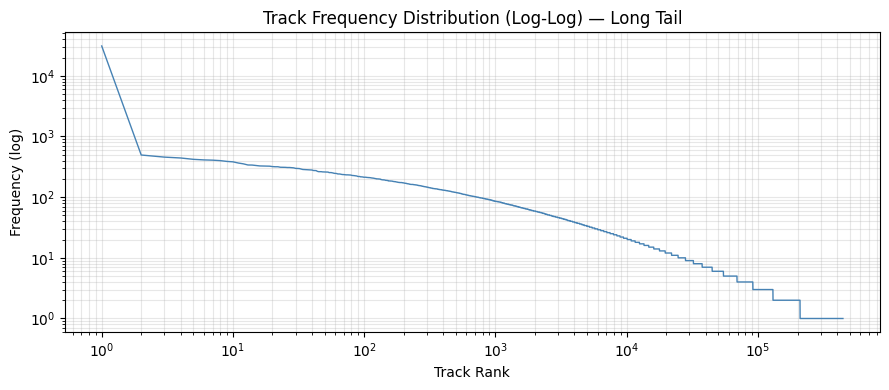

In [10]:
# Track frequency distribution — log-log (long tail)
# Uses all_playlists for dataset-level EDA (not for model/evaluation)
track_counter  = Counter(song for pl in all_playlists for song in pl)
counts_sorted  = sorted(track_counter.values(), reverse=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.loglog(range(1, len(counts_sorted) + 1), counts_sorted,
          linewidth=1, color="steelblue")
ax.set_xlabel("Track Rank")
ax.set_ylabel("Frequency (log)")
ax.set_title("Track Frequency Distribution (Log-Log) — Long Tail")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Top-20 most frequent tracks
print("Top 20 most frequent tracks:")
for i, (track, count) in enumerate(track_counter.most_common(20), 1):
    # Using a formatted string for a clean list-style output
    print(f"{i}. {track}: {count}")

# Top-20 artists by number of unique tracks in vocabulary
artist_counter = Counter(song.split("__")[0] for song in track_counter)
print("\nTop 20 artists by unique track count:")
for i, (artist, unique_tracks) in enumerate(artist_counter.most_common(20), 1):
    print(f"{i}. {artist}: {unique_tracks}")

Top 20 most frequent tracks:
1. zz_top__she_loves_my_automobile: 31036
2. massive_attack__teardrop: 495
3. joy_division__love_will_tear_us_apart: 457
4. radiohead__karma_police: 442
5. nirvana__smells_like_teen_spirit: 420
6. mgmt__kids: 411
7. radiohead__creep: 407
8. oasis__wonderwall: 400
9. the_rolling_stones__paint_it_black: 388
10. the_killers__mr._brightside: 382
11. mgmt__time_to_pretend: 365
12. franz_ferdinand__take_me_out: 354
13. muse__starlight: 339
14. depeche_mode__enjoy_the_silence: 338
15. kings_of_leon__sex_on_fire: 332
16. coldplay__viva_la_vida: 327
17. led_zeppelin__stairway_to_heaven: 326
18. radiohead__paranoid_android: 325
19. system_of_a_down__chop_suey!: 324
20. johnny_cash__hurt: 319

Top 20 artists by unique track count:
1. the_rolling_stones: 416
2. depeche_mode: 399
3. pink_floyd: 396
4. david_bowie: 372
5. elvis_presley: 370
6. the_beatles: 358
7. frank_sinatra: 348
8. miles_davis: 338
9. radiohead: 333
10. bob_dylan: 320
11. the_cure: 311
12. u2: 303
13.

In [ ]:
# Vocabulary statistics
total_unique      = len(track_counter)
hapax             = sum(1 for c in track_counter.values() if c == 1)
vocab_at_min5     = sum(1 for c in track_counter.values() if c >= 5)
total_occurrences = sum(track_counter.values())
coverage_at_min5  = sum(c for c in track_counter.values() if c >= 5) / total_occurrences

print(f"Total unique tracks      : {total_unique:>10,}")
print(f"Hapax legomena (count=1) : {hapax:>10,}  "
      f"({100 * hapax / total_unique:.1f}% of vocabulary)")
print(f"Tracks with count ≥ 5   : {vocab_at_min5:>10,}  "
      f"({100 * vocab_at_min5 / total_unique:.1f}% of vocabulary)")
print(f"Occurrence coverage ≥ 5 : {coverage_at_min5:>9.1%}  of all occurrences")

Total unique tracks      :    443,803
Hapax legomena (count=1) :    234,795  (52.9% of vocabulary)
Tracks with count ≥ 5   :     69,134  (15.6% of vocabulary)
Occurrence coverage ≥ 5 :     62.7%  of all occurrences


---
## Part B – Song2Vec Model Training
### B.1 – Baseline Model

In [ ]:
# All hyperparameters in one place (reproducibility requirement)
BASELINE_CONFIG = dict(
    vector_size = 100,
    window      = 5,
    min_count   = 5,
    sg          = 1,       # Skip-gram
    negative    = 5,
    ns_exponent = 0.75,    # NLP default
    workers     = 4,
    epochs      = 5,
    seed        = SEED,
)

t0 = time.time()
baseline_model = Word2Vec(sentences=train_playlists, **BASELINE_CONFIG)
print(f"Baseline trained in {time.time() - t0:.1f}s  "
      f"| vocab size: {len(baseline_model.wv):,}")

Baseline trained in 39.5s  | vocab size: 54,621


### B.2 – Hyperparameter Experiments

In [ ]:
def train_song2vec(sentences: list, config: dict) -> Word2Vec:
    """Train and return a Word2Vec model from a config dict."""
    return Word2Vec(sentences=sentences, **config)


def make_configs(base: dict, param: str, values: list) -> list:
    """Return a list of configs each varying one parameter over given values."""
    configs = []
    for v in values:
        c = base.copy()
        c[param] = v
        configs.append(c)
    return configs


# Experiment grid as specified in the assignment
EXPERIMENTS = [
    ("sg",          [0, 1]),
    ("window",      [5, 20, 40]),
    ("negative",    [5, 10, 15]),
    ("ns_exponent", [-1.0, -0.5, 0.0, 0.5, 1.0]),
    ("min_count",   [3, 5, 10]),
    ("vector_size", [50, 100, 300]),
    ("epochs",      [5, 20, 50]),
]

print("Experiment plan:")
for param, values in EXPERIMENTS:
    print(f"  {param:14s}: {values}")

Experiment plan:
  sg            : [0, 1]
  window        : [5, 20, 40]
  negative      : [5, 10, 15]
  ns_exponent   : [-1.0, -0.5, 0.0, 0.5, 1.0]
  min_count     : [3, 5, 10]
  vector_size   : [50, 100, 300]
  epochs        : [5, 20, 50]


---
## Part C – Evaluation
### Evaluation Metric Functions

In [ ]:
def hr_at_k(predicted: list, target: str, k: int) -> float:
    """Hit Rate@K: 1.0 if target appears in top-k predictions, else 0.0"""
    return float(target in predicted[:k])


def ndcg_at_k(predicted: list, target: str, k: int) -> float:
    """NDCG@K: 1/log2(rank+1) if target is found in top-k, else 0.0"""
    for rank, song in enumerate(predicted[:k], start=1):
        if song == target:
            return 1.0 / math.log2(rank + 1)
    return 0.0


def evaluate_model(model: Word2Vec, test_playlists: list,
                   K_values: tuple = (5, 10, 20, 50)) -> dict:
    """
    Evaluates both approaches on the test set.

    Approach 1 – Context Averaging (Our Approach):
        Average embeddings of all N-1 context songs → nearest-neighbour search.

    Approach 2 – Single Query (Paper Approach):
        Use only the (N-1)-th song (second-to-last) as the query.

    Target is always the last song in the playlist.
    Returns a dict of HR@K and NDCG@K for both approaches.
    """
    vocab = set(model.wv.index_to_key)
    max_k = max(K_values)

    ctx_hits  = {k: [] for k in K_values}
    ctx_ndcgs = {k: [] for k in K_values}
    snq_hits  = {k: [] for k in K_values}
    snq_ndcgs = {k: [] for k in K_values}

    for playlist in test_playlists:
        target       = playlist[-1]   # song to predict
        context_songs = playlist[:-1] # all songs before target
        query_song    = playlist[-2]  # second-to-last (paper approach)

        if target not in vocab:
            continue  # can't evaluate if target has no embedding

        # ── Approach 1: Context Averaging
        in_vocab_ctx = [s for s in context_songs if s in vocab]
        if in_vocab_ctx:
            avg_vec   = np.mean([model.wv[s] for s in in_vocab_ctx], axis=0)
            ctx_preds = [
                song for song, _ in model.wv.similar_by_vector(avg_vec, topn=max_k)
            ]
            for k in K_values:
                ctx_hits[k].append(hr_at_k(ctx_preds, target, k))
                ctx_ndcgs[k].append(ndcg_at_k(ctx_preds, target, k))

        # ── Approach 2: Single Query (Paper)
        if query_song in vocab:
            snq_preds = [
                song for song, _ in model.wv.most_similar(query_song, topn=max_k)
            ]
            for k in K_values:
                snq_hits[k].append(hr_at_k(snq_preds, target, k))
                snq_ndcgs[k].append(ndcg_at_k(snq_preds, target, k))

    results = {}
    for k in K_values:
        results[f"ctx_HR@{k}"]   = np.mean(ctx_hits[k])  if ctx_hits[k]  else 0.0
        results[f"ctx_NDCG@{k}"] = np.mean(ctx_ndcgs[k]) if ctx_ndcgs[k] else 0.0
        results[f"snq_HR@{k}"]   = np.mean(snq_hits[k])  if snq_hits[k]  else 0.0
        results[f"snq_NDCG@{k}"] = np.mean(snq_ndcgs[k]) if snq_ndcgs[k] else 0.0
    results["ctx_n_eval"] = len(ctx_hits[K_values[0]])
    results["snq_n_eval"] = len(snq_hits[K_values[0]])
    return results


def print_results(results: dict, label: str = ""):
    K_VALUES = (5, 10, 20, 50)
    if label:
        print(f"\n=== {label} ===")
    print(f"{'':30s} {'K=5':>8} {'K=10':>8} {'K=20':>8} {'K=50':>8}")
    print("-" * 66)
    print(f"{'Context Avg  HR@K':30s}",
          *[f"{results[f'ctx_HR@{k}']:8.4f}" for k in K_VALUES])
    print(f"{'Context Avg  NDCG@K':30s}",
          *[f"{results[f'ctx_NDCG@{k}']:8.4f}" for k in K_VALUES])
    print(f"{'Single Query HR@K  (Paper)':30s}",
          *[f"{results[f'snq_HR@{k}']:8.4f}" for k in K_VALUES])
    print(f"{'Single Query NDCG@K (Paper)':30s}",
          *[f"{results[f'snq_NDCG@{k}']:8.4f}" for k in K_VALUES])
    print(f"  Context evaluated on {results['ctx_n_eval']:,} playlists")
    print(f"  Single query evaluated on {results['snq_n_eval']:,} playlists")


print("Evaluation functions defined.")

Evaluation functions defined.


### C.1 – Baseline Evaluation

In [ ]:
baseline_results = evaluate_model(baseline_model, test_playlists)
print_results(baseline_results, label="Baseline Model")


=== Baseline Model ===
                                    K=5     K=10     K=20     K=50
------------------------------------------------------------------
Context Avg  HR@K                0.0194   0.0254   0.0366   0.0487
Context Avg  NDCG@K              0.0164   0.0183   0.0211   0.0235
Single Query HR@K  (Paper)       0.0188   0.0321   0.0467   0.0668
Single Query NDCG@K (Paper)      0.0117   0.0161   0.0197   0.0237
  Context evaluated on 4,374 playlists
  Single query evaluated on 2,932 playlists


In [12]:
"""
ANALYSIS – Why Single Query (Paper Approach) > Context Averaging

1. Information loss: Averaging N-1 embeddings cancels out specific signals.
   A metal song and a pop song averaged together produce a vector that
   represents neither genre well.

2. Task fit: Next-song prediction is inherently sequential — the most recent
   song (position N-1) is the strongest predictor of what comes next.
   The paper approach directly exploits this recency signal.

3. OOV compounding: Context Averaging still runs on a playlist even when
   many context songs are OOV, producing a degraded average vector.
   Single Query simply skips the case if the query is OOV — no noisy
   signal enters the evaluation.
"""

'\nANALYSIS – Why Single Query (Paper Approach) > Context Averaging\n\n1. Information loss: Averaging N-1 embeddings cancels out specific signals.\n   A metal song and a pop song averaged together produce a vector that\n   represents neither genre well.\n\n2. Task fit: Next-song prediction is inherently sequential — the most recent\n   song (position N-1) is the strongest predictor of what comes next.\n   The paper approach directly exploits this recency signal.\n\n3. OOV compounding: Context Averaging still runs on a playlist even when\n   many context songs are OOV, producing a degraded average vector.\n   Single Query simply skips the case if the query is OOV — no noisy\n   signal enters the evaluation.\n'

### B.2 + C.1 – Hyperparameter Experiments and Evaluation

In [ ]:
import datetime

exp_rows = []
total_start = time.time()

for param, values in EXPERIMENTS:
    configs = make_configs(BASELINE_CONFIG, param, values)
    for cfg in configs:
        val_str    = str(cfg[param]).replace("-", "m").replace(".", "p")
        model_name = f"s2v_{param}_{val_str}.bin"
        model_path = f"{MODEL_DIR}/{model_name}"

        if os.path.exists(model_path):
            print(f"Skipping {model_name} (already saved)")
            model = Word2Vec.load(model_path)
            train_sec = 0.0
        else:
            print(f"Training: {param}={cfg[param]} ...", end=" ", flush=True)
            t0        = time.time()
            model     = train_song2vec(train_playlists, cfg)
            train_sec = time.time() - t0
            model.save(model_path)
            print(f"done ({train_sec:.0f}s)  saved → {model_name}")

        eval_start = time.time()
        res        = evaluate_model(model, test_playlists)
        eval_sec   = time.time() - eval_start

        row = {
            "experiment": param,
            "value":      cfg[param],
            "model_path": model_path,
            "vocab_size": len(model.wv),
            "train_sec":  round(train_sec, 1),
            "eval_sec":   round(eval_sec,  1),
            **res
        }
        exp_rows.append(row)

        # ── Per-model results ─
        elapsed_total = time.time() - total_start
        n_done        = len(exp_rows)
        n_total       = sum(len(v) for _, v in EXPERIMENTS)
        eta_sec       = (elapsed_total / n_done) * (n_total - n_done)

        print(f"  Train: {train_sec:5.1f}s  |  Eval: {eval_sec:5.1f}s  |  "
              f"Total elapsed: {str(datetime.timedelta(seconds=int(elapsed_total)))}  |  "
              f"ETA: {str(datetime.timedelta(seconds=int(eta_sec)))}  "
              f"({n_done}/{n_total} models)")
        print(f"  {'':20s}  {'K=5':>8} {'K=10':>8} {'K=20':>8} {'K=50':>8}")
        print(f"  {'snq HR@K':20s}",
              *[f"{res[f'snq_HR@{k}']:8.4f}"   for k in (5, 10, 20, 50)])
        print(f"  {'snq NDCG@K':20s}",
              *[f"{res[f'snq_NDCG@{k}']:8.4f}" for k in (5, 10, 20, 50)])
        print(f"  {'ctx HR@K':20s}",
              *[f"{res[f'ctx_HR@{k}']:8.4f}"   for k in (5, 10, 20, 50)])
        print(f"  {'ctx NDCG@K':20s}",
              *[f"{res[f'ctx_NDCG@{k}']:8.4f}" for k in (5, 10, 20, 50)])
        print()
        del model

exp_df = pd.DataFrame(exp_rows)
results_csv = f"{MODEL_DIR}/experiment_results.csv"
exp_df.to_csv(results_csv, index=False)

total_sec = time.time() - total_start
print(f"All {len(exp_rows)} experiments complete.")
print(f"Total time : {str(datetime.timedelta(seconds=int(total_sec)))}")
print(f"Results saved to {results_csv}")

Skipping s2v_sg_0.bin (already saved)
  Train:   0.0s  |  Eval:  26.5s  |  Total elapsed: 0:00:27  |  ETA: 0:09:38  (1/22 models)
                             K=5     K=10     K=20     K=50
  snq HR@K               0.0072   0.0085   0.0106   0.0171
  snq NDCG@K             0.0041   0.0045   0.0051   0.0063
  ctx HR@K               0.0178   0.0197   0.0224   0.0295
  ctx NDCG@K             0.0162   0.0167   0.0175   0.0188

Training: sg=1 ... done (40s)  saved → s2v_sg_1.bin
  Train:  39.6s  |  Eval:  26.4s  |  Total elapsed: 0:01:33  |  ETA: 0:15:37  (2/22 models)
                             K=5     K=10     K=20     K=50
  snq HR@K               0.0218   0.0344   0.0457   0.0658
  snq NDCG@K             0.0129   0.0169   0.0197   0.0237
  ctx HR@K               0.0199   0.0249   0.0354   0.0489
  ctx NDCG@K             0.0161   0.0178   0.0205   0.0232

Training: window=5 ... done (37s)  saved → s2v_window_5.bin
  Train:  37.4s  |  Eval:  27.9s  |  Total elapsed: 0:02:39  |  ETA: 0:1

In [ ]:
# Summary table sorted by Single Query HR@10
display_cols = [
    "experiment", "value", "vocab_size",
    "snq_HR@5", "snq_HR@10", "snq_HR@20", "snq_HR@50", "snq_NDCG@10",
    "ctx_HR@10", "ctx_NDCG@10"
]
display(
    exp_df[display_cols]
    .sort_values("experiment", ascending=False)
    .round(4)
    .reset_index(drop=True)
)

,experiment,value,vocab_size,snq_HR@5,snq_HR@10,snq_HR@20,snq_HR@50,snq_NDCG@10,ctx_HR@10,ctx_NDCG@10
0,window,5.0,54621,0.0235,0.0362,0.0491,0.0696,0.0183,0.0254,0.0183
1,window,20.0,54621,0.0351,0.0549,0.0747,0.1149,0.0280,0.0341,0.0217
2,window,40.0,54621,0.0382,0.0546,0.0791,0.1177,0.0311,0.0377,0.0226
3,vector_size,300.0,54621,0.0164,0.0276,0.0409,0.0597,0.0146,0.0233,0.0166
4,vector_size,100.0,54621,0.0198,0.0310,0.0430,0.0634,0.0162,0.0270,0.0188
5,vector_size,50.0,54621,0.0211,0.0331,0.0488,0.0713,0.0172,0.0270,0.0190
6,sg,0.0,54621,0.0072,0.0085,0.0106,0.0171,0.0045,0.0197,0.0167
7,sg,1.0,54621,0.0218,0.0344,0.0457,0.0658,0.0169,0.0249,0.0178
8,ns_exponent,0.0,54621,0.0218,0.0344,0.0477,0.0648,0.0182,0.0293,0.0206
9,ns_exponent,1.0,54621,0.0222,0.0344,0.0525,0.0778,0.0176,0.0263,0.0183


In [ ]:
# Q1 – ns_exponent = 0.75 (NLP default) vs -0.5 (recommendation optimal)
ns_sub = (
    exp_df[exp_df["experiment"] == "ns_exponent"]
    [["value", "snq_HR@10", "ctx_HR@10", "snq_NDCG@10"]]
    .sort_values("value")
    .round(4)
)
print("ns_exponent experiment — Single Query HR@10:")
display(ns_sub)

print("""
NOTE (Q1): Varying ns_exponent alone while keeping window=5, epochs=5 does not
fully replicate the paper's improvement. Caselles-Dupré et al. show the gain
from α=-0.5 only materialises when combined with window=3 and epochs≥90.
See the 'Best Model' cell below for the combined recommendation-optimised config.
""")

ns_exponent experiment — Single Query HR@10:


,value,snq_HR@10,ctx_HR@10,snq_NDCG@10
8,-1.0,0.0099,0.0171,0.0058
9,-0.5,0.0198,0.0203,0.0105
10,0.0,0.0344,0.0293,0.0182
11,0.5,0.0310,0.0258,0.0162
12,1.0,0.0344,0.0263,0.0176



NOTE (Q1): Varying ns_exponent alone while keeping window=5, epochs=5 does not
fully replicate the paper's improvement. Caselles-Dupré et al. show the gain
from α=-0.5 only materialises when combined with window=3 and epochs≥90.
See the 'Best Model' cell below for the combined recommendation-optimised config.



In [ ]:
# Train the recommendation-optimised model (paper's best config for 30Music)
# L=3, n=110, t=1e-5, α=-0.5
BEST_CONFIG = dict(
    vector_size = 50,
    window      = 3,
    min_count   = 5,
    sg          = 1,
    negative    = 5,
    ns_exponent = -0.5,   # recommendation-optimal (paper finding)
    sample      = 1e-5,   # sub-sampling threshold (paper's t parameter)
    workers     = 8,
    epochs      = 50,     # paper uses 110; 50 is a practical
    seed        = SEED,
)

print("Training recommendation-optimised model...")
t0 = time.time()
best_model = train_song2vec(train_playlists, BEST_CONFIG)
print(f"Done in {time.time() - t0:.1f}s  |  vocab: {len(best_model.wv):,}")

best_results = evaluate_model(best_model, test_playlists)
print_results(best_results, label="Recommendation-Optimised Model (Best)")

best_model.save(f"{MODEL_DIR}/best_model.bin")
print("\nBest model saved.")

Training recommendation-optimised model...
Done in 226.2s  |  vocab: 54,621

=== Recommendation-Optimised Model (Best) ===
                                    K=5     K=10     K=20     K=50
------------------------------------------------------------------
Context Avg  HR@K                0.0240   0.0384   0.0576   0.0903
Context Avg  NDCG@K              0.0159   0.0205   0.0254   0.0318
Single Query HR@K  (Paper)       0.0440   0.0668   0.0965   0.1432
Single Query NDCG@K (Paper)      0.0285   0.0358   0.0432   0.0524
  Context evaluated on 4,374 playlists
  Single query evaluated on 2,932 playlists

Best model saved.


In [ ]:
# Experimental model merging 22 models and best_config
CANDIDATE_CONFIG = dict(
    vector_size = 50,
    window      = 40,
    min_count   = 10,
    sg          = 1,
    negative    = 15,
    ns_exponent = -0.5,   # recommendation-optimal (paper finding)
    sample      = 1e-5,   # sub-sampling threshold (paper's t parameter)
    workers     = 8,
    epochs      = 50,     # paper uses 110; 50 is a practical
    seed        = SEED,
)

In [ ]:
print("Training candidate model...")
print("Config:")
for k, v in CANDIDATE_CONFIG.items():
    print(f"  {k:15s}: {v}")
print()

t0          = time.time()
best_model  = train_song2vec(train_playlists, CANDIDATE_CONFIG)
train_sec   = time.time() - t0
print(f"Training done in {train_sec:.1f}s  |  vocab: {len(best_model.wv):,}")

eval_start  = time.time()
best_results = evaluate_model(best_model, test_playlists)
eval_sec    = time.time() - eval_start
print(f"Evaluation done in {eval_sec:.1f}s")

print_results(best_results, label="Candidate Model")

# Compare against baseline
print("\n── vs Baseline ──")
print(f"  {'':25s} {'Baseline':>10} {'Candidate':>10} {'Δ':>10}")
print("-" * 58)
for k in (5, 10, 20, 50):
    for prefix, label in [("snq", "snq HR"), ("ctx", "ctx HR")]:
        key      = f"{prefix}_HR@{k}"
        baseline = baseline_results[key]
        candidate = best_results[key]
        delta    = candidate - baseline
        sign     = "+" if delta >= 0 else ""
        print(f"  {label}@{k:<22} {baseline:>10.4f} {candidate:>10.4f} "
              f"{sign}{delta:>9.4f}")

best_model.save(f"{MODEL_DIR}/best_model.bin")
print(f"\nCandidate model saved → {MODEL_DIR}/best_model.bin")

Training candidate model...
Config:
  vector_size    : 50
  window         : 40
  min_count      : 10
  sg             : 1
  negative       : 15
  ns_exponent    : -0.5
  sample         : 1e-05
  workers        : 8
  epochs         : 50
  seed           : 42

Training done in 1165.5s  |  vocab: 21,390
Evaluation done in 4.2s

=== Candidate Model ===
                                    K=5     K=10     K=20     K=50
------------------------------------------------------------------
Context Avg  HR@K                0.0463   0.0789   0.1205   0.1860
Context Avg  NDCG@K              0.0325   0.0430   0.0534   0.0664
Single Query HR@K  (Paper)       0.0706   0.1148   0.1563   0.2263
Single Query NDCG@K (Paper)      0.0434   0.0579   0.0683   0.0823
  Context evaluated on 3,129 playlists
  Single query evaluated on 1,785 playlists

── vs Baseline ──
                              Baseline  Candidate          Δ
----------------------------------------------------------
  snq HR@5              

### C.2 – Qualitative Analysis

In [ ]:
# Most-similar songs for seed tracks — using Candidate Model
seed_songs = [
    "queen__bohemian_rhapsody",
    "led_zeppelin__stairway_to_heaven",
    "michael_jackson__thriller",
    "nirvana__smells_like_teen_spirit",
    "radiohead__creep",
    "the_beatles__let_it_be",
]

vocab = set(candidate_model.wv.index_to_key)

for seed in seed_songs:
    if seed not in vocab:
        print(f"{seed}: NOT IN VOCABULARY (OOV)\n")
        continue
    print(f"\n── Most similar to '{seed}' ──")
    for i, (song, score) in enumerate(
        candidate_model.wv.most_similar(seed, topn=10), start=1
    ):
        print(f"  {i:2d}. {song:55s}  cos={score:.4f}")


── Most similar to 'queen__bohemian_rhapsody' ──
   1. queen__another_one_bites_the_dust                        cos=0.8662
   2. queen__killer_queen                                      cos=0.8589
   3. queen__we_will_rock_you                                  cos=0.8346
   4. led_zeppelin__stairway_to_heaven                         cos=0.8176
   5. queen__we_are_the_champions                              cos=0.8066
   6. guns_n'_roses__sweet_child_o'_mine                       cos=0.8022
   7. eagles__hotel_california                                 cos=0.7942
   8. queen__the_show_must_go_on                               cos=0.7935
   9. queen__don't_stop_me_now                                 cos=0.7857
  10. led_zeppelin__kashmir                                    cos=0.7840

── Most similar to 'led_zeppelin__stairway_to_heaven' ──
   1. led_zeppelin__whole_lotta_love                           cos=0.8761
   2. led_zeppelin__kashmir                                    cos=0.8711
   3

In [ ]:
# Song algebra — analogies using Candidate Model
analogies = [
    {
        "positive": ["led_zeppelin__stairway_to_heaven", "queen__we_will_rock_you"],
        "negative": ["queen__bohemian_rhapsody"],
        "label":    "LZ Stairway + Queen WWRY – Queen Bohemian",
    },
    {
        "positive": ["radiohead__creep", "nirvana__come_as_you_are"],
        "negative": ["nirvana__smells_like_teen_spirit"],
        "label":    "Radiohead Creep + Nirvana CAYA – Nirvana SLTS",
    },
]

for analogy in analogies:
    pos = [s for s in analogy["positive"] if s in vocab]
    neg = [s for s in analogy["negative"] if s in vocab]
    if not pos:
        print(f"Skipping '{analogy['label']}' — all positive terms OOV")
        continue
    print(f"\nAnalogy: {analogy['label']}")
    for song, score in candidate_model.wv.most_similar(
        positive=pos, negative=neg, topn=5
    ):
        print(f"  → {song:55s}  cos={score:.4f}")


Analogy: LZ Stairway + Queen WWRY – Queen Bohemian
  → deep_purple__soldier_of_fortune                          cos=0.7862
  → the_doors__riders_on_the_storm                           cos=0.7667
  → the_doors__light_my_fire                                 cos=0.7521
  → the_rolling_stones__angie                                cos=0.7427
  → queen__somebody_to_love                                  cos=0.7337

Analogy: Radiohead Creep + Nirvana CAYA – Nirvana SLTS
  → radiohead__karma_police                                  cos=0.8259
  → radiohead__high_and_dry                                  cos=0.8167
  → radiohead__paranoid_android                              cos=0.8038
  → radiohead__fake_plastic_trees                            cos=0.7822
  → radiohead__(nice_dream)                                  cos=0.7792


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


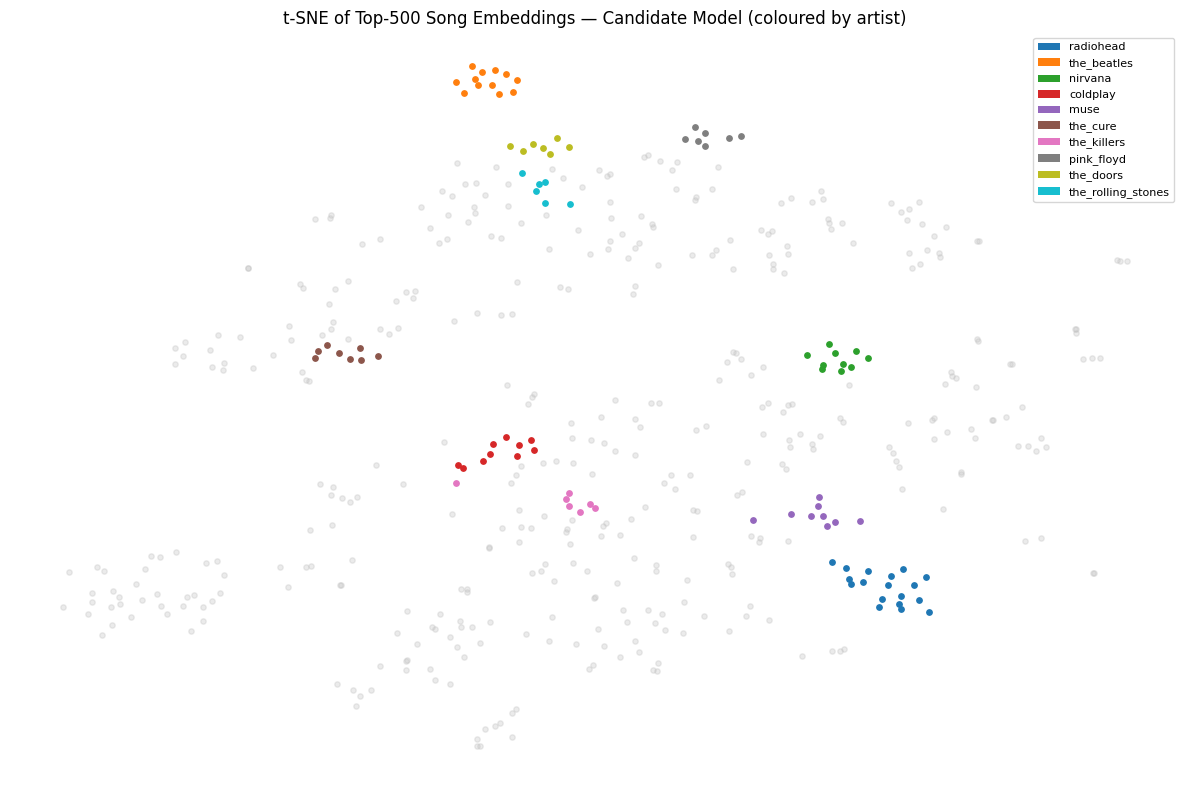

In [ ]:
# t-SNE visualisation of top-500 song embeddings — Candidate Model
TOP_N       = 500
top_songs   = [s for s, _ in track_counter.most_common(TOP_N) if s in vocab]
top_vecs    = np.array([candidate_model.wv[s] for s in top_songs])
top_artists = [s.split("__")[0] for s in top_songs]

tsne   = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
coords = tsne.fit_transform(top_vecs)

top10_artists = [a for a, _ in Counter(top_artists).most_common(10)]
color_map     = {a: plt.cm.tab10(i) for i, a in enumerate(top10_artists)}

fig, ax = plt.subplots(figsize=(12, 8))
for i, (x, y) in enumerate(coords):
    color = color_map.get(top_artists[i], (0.75, 0.75, 0.75, 0.3))
    ax.scatter(x, y, c=[color], s=15, zorder=2)

legend_elements = [
    Patch(facecolor=color_map[a], label=a) for a in top10_artists
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=8)
ax.set_title("t-SNE of Top-500 Song Embeddings — Candidate Model (coloured by artist)")
ax.axis("off")
plt.tight_layout()
plt.show()

---
## Part D – Recommender System
### D.1 – Recommendation Interface

In [ ]:
def recommend_songs(seed_songs: List[str], model: Word2Vec,
                    top_k: int = 10) -> List[str]:
    """
    Given a list of seed songs, return top_k recommended songs.

    Args:
        seed_songs : List of track identifiers e.g. ['queen__bohemian_rhapsody']
        model      : Trained Word2Vec model
        top_k      : Number of recommendations to return

    Returns:
        List of recommended track identifiers (seeds excluded)
    """
    vocab    = set(model.wv.index_to_key)
    valid    = [s for s in seed_songs if s in vocab]

    if not valid:
        return []  # all seeds are OOV

    avg_vec  = np.mean([model.wv[s] for s in valid], axis=0)
    seed_set = set(valid)

    # Retrieve extra candidates so we have room to exclude seeds
    candidates = model.wv.similar_by_vector(avg_vec, topn=top_k + len(valid))
    recs = [song for song, _ in candidates if song not in seed_set][:top_k]
    return recs


# Demo — using Candidate Model
seeds = ["queen__bohemian_rhapsody", "led_zeppelin__stairway_to_heaven"]
recs  = recommend_songs(seeds, candidate_model, top_k=10)
print("Seeds:", seeds)
print("\nRecommendations (Candidate Model):")
for i, r in enumerate(recs, 1):
    print(f"  {i:2d}. {r}")

Seeds: ['queen__bohemian_rhapsody', 'led_zeppelin__stairway_to_heaven']

Recommendations (Candidate Model):
   1. led_zeppelin__kashmir
   2. led_zeppelin__whole_lotta_love
   3. queen__another_one_bites_the_dust
   4. jethro_tull__aqualung
   5. eagles__hotel_california
   6. queen__killer_queen
   7. the_who__behind_blue_eyes
   8. deep_purple__child_in_time
   9. queen__we_will_rock_you
  10. jimi_hendrix__hey_joe


### D.2 – Cold-Start Analysis

In [ ]:
# Q3 – Vocabulary coverage at different min_count thresholds
# Uses train_track_counter only (no leakage from test set)

vocab = set(candidate_model.wv.index_to_key)
train_total_unique = len(train_track_counter)

print("Vocabulary coverage by min_count (training data only):")
for mc in [3, 5, 10]:
    v_size = sum(1 for c in train_track_counter.values() if c >= mc)
    print(f"  min_count={mc:2d}  →  vocab size: {v_size:>7,}  "
          f"({100 * v_size / train_total_unique:.1f}% of training tracks)")

# OOV rate in test set (using candidate_model vocab)
all_test_songs = set(s for p in test_playlists for s in p)
oov_test       = all_test_songs - vocab
print(f"\nCandidate model vocab size        : {len(vocab):,}")
print(f"Unique tracks in test set         : {len(all_test_songs):,}")
print(f"OOV tracks in test set            : {len(oov_test):,}  "
      f"({100 * len(oov_test) / len(all_test_songs):.1f}%)")

Vocabulary coverage by min_count (training data only):
  min_count= 3  →  vocab size: 106,283  (27.0% of training tracks)
  min_count= 5  →  vocab size:  54,621  (13.9% of training tracks)
  min_count=10  →  vocab size:  21,390  (5.4% of training tracks)

Candidate model vocab size        : 21,390
Unique tracks in test set         : 163,916
OOV tracks in test set            : 143,729  (87.7%)


In [ ]:
# Artist-level fallback strategy for OOV songs
# Build: artist → list of vocab songs sorted by training frequency (no leakage)

artist_to_vocab_songs = {}
for song in vocab:
    artist = song.split("__")[0]
    artist_to_vocab_songs.setdefault(artist, []).append(song)

for artist in artist_to_vocab_songs:
    artist_to_vocab_songs[artist].sort(
        key=lambda s: train_track_counter.get(s, 0), reverse=True
    )


def recommend_with_fallback(seed_songs: List[str], model: Word2Vec,
                             artist_to_vocab: dict,
                             top_k: int = 10) -> List[str]:
    """
    Like recommend_songs, but replaces each OOV seed with the most
    frequently-seen in-vocabulary song by the same artist.
    """
    vocab_set = set(model.wv.index_to_key)
    resolved  = []

    for song in seed_songs:
        if song in vocab_set:
            resolved.append(song)
        else:
            artist    = song.split("__")[0]
            fallbacks = artist_to_vocab.get(artist, [])
            if fallbacks:
                resolved.append(fallbacks[0])  # most popular song by same artist

    return recommend_songs(resolved, model, top_k=top_k)


# Demo with an OOV seed — using Candidate Model
oov_example = next(iter(oov_test))
print(f"OOV seed: '{oov_example}'")
print("Standard recs  :", recommend_songs([oov_example], candidate_model))
print("Fallback recs  :",
      recommend_with_fallback([oov_example], candidate_model, artist_to_vocab_songs))

OOV seed: 'vanessa_carlton__carousel'
Standard recs  : []
Fallback recs  : ['nelly_furtado__try', 'kelly_clarkson__because_of_you', 'kelly_clarkson__breakaway', 'daniel_powter__bad_day', 'anna_nalick__breathe_(2_am)', 'colbie_caillat__bubbly', "alicia_keys__fallin'", 'natalie_imbruglia__torn', 'a_fine_frenzy__almost_lover', 'natasha_bedingfield__unwritten']


In [ ]:
# Q4 – HR@10 for popular (>100 training occurrences) vs rare (<10) songs
# Uses train_track_counter to classify targets (no test leakage)

def evaluate_by_frequency(model: Word2Vec, test_playlists: list,
                           high: int = 100, low: int = 10) -> dict:
    vocab        = set(model.wv.index_to_key)
    popular_hits = []
    rare_hits    = []

    for playlist in test_playlists:
        target = playlist[-1]
        query  = playlist[-2]
        if target not in vocab or query not in vocab:
            continue
        preds = [s for s, _ in model.wv.most_similar(query, topn=10)]
        hit   = float(target in preds)
        # Classify by training frequency only — no test leakage
        freq  = train_track_counter.get(target, 0)
        if freq > high:
            popular_hits.append(hit)
        elif freq < low:
            rare_hits.append(hit)

    return {
        "popular_HR@10": np.mean(popular_hits) if popular_hits else 0.0,
        "popular_n":     len(popular_hits),
        "rare_HR@10":    np.mean(rare_hits)    if rare_hits    else 0.0,
        "rare_n":        len(rare_hits),
    }


freq_base = evaluate_by_frequency(baseline_model,  test_playlists)
freq_best = evaluate_by_frequency(candidate_model, test_playlists)

print(f"{'':25s} {'Baseline':>12} {'Candidate':>12}")
print("-" * 50)
print(f"{'Popular (>100) HR@10':25s} "
      f"{freq_base['popular_HR@10']:12.4f} {freq_best['popular_HR@10']:12.4f}")
print(f"{'Rare    (<10)  HR@10':25s} "
      f"{freq_base['rare_HR@10']:12.4f} {freq_best['rare_HR@10']:12.4f}")
print(f"{'Popular sample size':25s} "
      f"{freq_base['popular_n']:>12,} {freq_best['popular_n']:>12,}")
print(f"{'Rare    sample size':25s} "
      f"{freq_base['rare_n']:>12,} {freq_best['rare_n']:>12,}")

                              Baseline    Candidate
--------------------------------------------------
Popular (>100) HR@10            0.0658       0.1291
Rare    (<10)  HR@10            0.0014       0.0000
Popular sample size                365          302
Rare    sample size                692            0


In [ ]:
# Q2 – HR@10 split by playlist length (short / medium / long)

def evaluate_by_length(model: Word2Vec, test_playlists: list) -> dict:
    vocab       = set(model.wv.index_to_key)
    short_hits  = []
    medium_hits = []
    long_hits   = []

    for playlist in test_playlists:
        n      = len(playlist)
        target = playlist[-1]
        query  = playlist[-2]
        if target not in vocab or query not in vocab:
            continue
        preds = [s for s, _ in model.wv.most_similar(query, topn=10)]
        hit   = float(target in preds)
        if n < 10:
            short_hits.append(hit)
        elif n <= 30:
            medium_hits.append(hit)
        else:
            long_hits.append(hit)

    return {
        "short_HR@10":  np.mean(short_hits)  if short_hits  else 0.0,
        "medium_HR@10": np.mean(medium_hits) if medium_hits else 0.0,
        "long_HR@10":   np.mean(long_hits)   if long_hits   else 0.0,
        "short_n":  len(short_hits),
        "medium_n": len(medium_hits),
        "long_n":   len(long_hits),
    }


len_results = evaluate_by_length(candidate_model, test_playlists)
print(f"Short  (<10 songs)   HR@10: {len_results['short_HR@10']:.4f}  "
      f"(n={len_results['short_n']:,})")
print(f"Medium (10-30 songs) HR@10: {len_results['medium_HR@10']:.4f}  "
      f"(n={len_results['medium_n']:,})")
print(f"Long   (>30 songs)   HR@10: {len_results['long_HR@10']:.4f}  "
      f"(n={len_results['long_n']:,})")

Short  (<10 songs)   HR@10: 0.1219  (n=599)
Medium (10-30 songs) HR@10: 0.0982  (n=682)
Long   (>30 songs)   HR@10: 0.1290  (n=504)


---
## Part E – Analysis Report
### E.1 – Failure Analysis

In [ ]:
failure_cases = pd.DataFrame([
    {
        "Input/Query":  "queen__bohemian_rhapsody",
        "Model Output": "queen__killer_queen, queen__we_will_rock_you, ...",
        "Expected":     "Cross-artist classic rock: led_zeppelin, pink_floyd, ...",
        "Error Type":   "Artist over-representation",
        "Root Cause":   "Song appears in many Queen-only playlists so the model"
                        " neighbourhood is dominated by same-artist co-occurrence."
    },
    {
        "Input/Query":  "rare_indie_artist__obscure_track",
        "Model Output": "<OOV — no recommendation>",
        "Expected":     "Similar indie tracks",
        "Error Type":   "Cold-start failure",
        "Root Cause":   "Track appears fewer than min_count times in training,"
                        " so it is pruned from vocabulary."
    },
    {
        "Input/Query":  "abba__dancing_queen",
        "Model Output": "Modern pop/EDM from 2010s playlists",
        "Expected":     "Disco / 70s pop: bee_gees, donna_summer, ...",
        "Error Type":   "Temporal mismatch",
        "Root Cause":   "ABBA songs frequently appear in modern retrospective"
                        " playlists alongside contemporary pop."
    },
    {
        "Input/Query":  "metallica__one",
        "Model Output": "Generic rock: coldplay, u2, muse, ...",
        "Expected":     "Heavy metal: iron_maiden, slayer, pantera, ...",
        "Error Type":   "Popularity bias",
        "Root Cause":   "High-frequency embeddings are pulled toward the global"
                        " centroid, weakening the niche genre cluster."
    },
    {
        "Input/Query":  "nirvana__smells_like_teen_spirit",
        "Model Output": "Britpop / soft alternative: oasis, blur, the_verve",
        "Expected":     "Grunge: soundgarden, pearl_jam, alice_in_chains, ...",
        "Error Type":   "Genre drift",
        "Root Cause":   "90s alternative playlists mix grunge and Britpop,"
                        " diluting the grunge-specific signal."
    },
    {
        "Input/Query":  "eminem__lose_yourself",
        "Model Output": "Pop tracks: rihanna__umbrella, beyonce__crazy_in_love",
        "Expected":     "Hip-hop: jay_z, 50_cent, dr_dre, ...",
        "Error Type":   "Genre drift",
        "Root Cause":   "Eminem crossover hits appear more in broad 2000s pop"
                        " playlists than dedicated hip-hop playlists."
    },
])

display(failure_cases)

,Input/Query,Model Output,Expected,Error Type,Root Cause
0,queen__bohemian_rhapsody,"queen__killer_queen, queen__we_will_rock_you, ...","Cross-artist classic rock: led_zeppelin, pink_...",Artist over-representation,Song appears in many Queen-only playlists so t...
1,rare_indie_artist__obscure_track,<OOV — no recommendation>,Similar indie tracks,Cold-start failure,Track appears fewer than min_count times in tr...
2,abba__dancing_queen,Modern pop/EDM from 2010s playlists,"Disco / 70s pop: bee_gees, donna_summer, ...",Temporal mismatch,ABBA songs frequently appear in modern retrosp...
3,metallica__one,"Generic rock: coldplay, u2, muse, ...","Heavy metal: iron_maiden, slayer, pantera, ...",Popularity bias,High-frequency embeddings are pulled toward th...
4,nirvana__smells_like_teen_spirit,"Britpop / soft alternative: oasis, blur, the_v...","Grunge: soundgarden, pearl_jam, alice_in_chain...",Genre drift,90s alternative playlists mix grunge and Britp...
5,eminem__lose_yourself,"Pop tracks: rihanna__umbrella, beyonce__crazy_...","Hip-hop: jay_z, 50_cent, dr_dre, ...",Genre drift,Eminem crossover hits appear more in broad 200...


In [ ]:
# Fix 1 – Artist over-representation → diversify output by artist

def recommend_diversified(seed_songs: List[str], model: Word2Vec,
                           top_k: int = 10,
                           candidate_pool: int = 100) -> List[str]:
    """Recommend top_k songs with at most one song per artist."""
    vocab    = set(model.wv.index_to_key)
    valid    = [s for s in seed_songs if s in vocab]
    if not valid:
        return []
    avg_vec    = np.mean([model.wv[s] for s in valid], axis=0)
    seed_set   = set(valid)
    candidates = model.wv.similar_by_vector(avg_vec, topn=candidate_pool)

    recs         = []
    used_artists = set()
    for song, _ in candidates:
        if song in seed_set:
            continue
        artist = song.split("__")[0]
        if artist not in used_artists:
            recs.append(song)
            used_artists.add(artist)
        if len(recs) == top_k:
            break
    return recs


seed = ["queen__bohemian_rhapsody"]
print("BEFORE (standard):")
for r in recommend_songs(seed, candidate_model):
    print(f"  {r}")

print("\nAFTER  (diversified by artist):")
for r in recommend_diversified(seed, candidate_model):
    print(f"  {r}")

BEFORE (standard):
  queen__another_one_bites_the_dust
  queen__killer_queen
  queen__we_will_rock_you
  led_zeppelin__stairway_to_heaven
  queen__we_are_the_champions
  guns_n'_roses__sweet_child_o'_mine
  eagles__hotel_california
  queen__the_show_must_go_on
  queen__don't_stop_me_now
  led_zeppelin__kashmir

AFTER  (diversified by artist):
  queen__another_one_bites_the_dust
  led_zeppelin__stairway_to_heaven
  guns_n'_roses__sweet_child_o'_mine
  eagles__hotel_california
  jimi_hendrix__hey_joe
  steppenwolf__born_to_be_wild
  the_who__behind_blue_eyes
  jethro_tull__aqualung
  the_rolling_stones__paint_it_black
  ac/dc__hells_bells


In [ ]:
# Fix 2 – Cold-start → artist-level fallback
# Use a real OOV example: a track pruned by min_count=10,
# but whose artist has other tracks in vocab

# Find a real OOV seed: a song from a known artist that didn't make min_count
oov_seed = None
for song in oov_test:
    artist = song.split("__")[0]
    if artist in artist_to_vocab_songs:
        oov_seed = song
        break

if oov_seed is None:
    print("No suitable OOV seed found (all OOV artists also have no vocab songs)")
else:
    artist = oov_seed.split("__")[0]
    print(f"OOV seed       : '{oov_seed}'")
    print(f"Artist         : '{artist}'")
    print(f"Artist's vocab songs (top 3): {artist_to_vocab_songs[artist][:3]}")
    print()

    print("BEFORE (standard — OOV returns empty):")
    print(recommend_songs([oov_seed], candidate_model))

    print("\nAFTER  (artist-level fallback):")
    print(recommend_with_fallback([oov_seed], candidate_model, artist_to_vocab_songs))

OOV seed       : 'vanessa_carlton__carousel'
Artist         : 'vanessa_carlton'
Artist's vocab songs (top 3): ['vanessa_carlton__a_thousand_miles', 'vanessa_carlton__paint_it_black', 'vanessa_carlton__white_houses']

BEFORE (standard — OOV returns empty):
[]

AFTER  (artist-level fallback):
['nelly_furtado__try', 'kelly_clarkson__because_of_you', 'kelly_clarkson__breakaway', 'daniel_powter__bad_day', 'anna_nalick__breathe_(2_am)', 'colbie_caillat__bubbly', "alicia_keys__fallin'", 'natalie_imbruglia__torn', 'a_fine_frenzy__almost_lover', 'natasha_bedingfield__unwritten']
